<a href="https://colab.research.google.com/github/Hussain800/Project-Urban/blob/main/CNN_Urban_Expansion_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install necessary tools (Rasterio handles satellite images)
!pip install rasterio

import rasterio
import numpy as np
import cv2
import os
from tqdm import tqdm
import shutil

# 2. Setup Directories
input_tif = "/Dubai_Full_Map_2024_revised.tif"
output_dir = "dataset/"

# Clean up old runs
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

# Flders for the CNN
os.makedirs(output_dir + "built", exist_ok=True)
os.makedirs(output_dir + "not_built", exist_ok=True)

print("🚀 Starting to process the satellite image...")

# 3. Slice it
with rasterio.open(input_tif) as src:
    # Read the image data
    # Bands: 1=Red, 2=Green, 3=Blue, 4=Label (Built/Not Built)
    img = src.read()

    # Normalize RGB bands to 0-255 range for standard image viewing
    # Fixing satellite data (scaling)
    rgb = img[:3, :, :]
    rgb = np.clip(rgb * 255, 0, 255).astype(np.uint8)

    # Extract the Label band (Band 4)
    labels = img[3, :, :]

    # Loop through the image in 64x64 chunks
    tile_size = 64
    rows = img.shape[1] // tile_size
    cols = img.shape[2] // tile_size

    count = 0
    built_count = 0

    for r in tqdm(range(rows)):
        for c in range(cols):
            # Calculate coordinates
            r1, r2 = r*tile_size, (r+1)*tile_size
            c1, c2 = c*tile_size, (c+1)*tile_size

            # Cut out the label chip
            label_chip = labels[r1:r2, c1:c2]

            # Skip empty edges (if the map has black borders)
            if label_chip.size == 0 or np.max(label_chip) == 0 and np.min(label_chip) == 0 and np.mean(rgb[:, r1:r2, c1:c2]) == 0:
                continue

            # Decide: Is this tile "Built" or "Not Built"?
            # If more than 10% of the pixels are built, we classify the whole tile as Built
            if np.mean(label_chip) > 0.1:
                category = "built"
                built_count += 1
            else:
                category = "not_built"

            # Cut out the RGB chip
            tile_rgb = rgb[:, r1:r2, c1:c2]

            # Rearrange dimensions for OpenCV (Channels Last: H, W, C)
            tile_img = np.moveaxis(tile_rgb, 0, -1)

            # Convert RGB to BGR (because OpenCV loves BGR)
            tile_img = cv2.cvtColor(tile_img, cv2.COLOR_RGB2BGR)

            # Save the image
            cv2.imwrite(f"{output_dir}{category}/tile_{count}.png", tile_img)
            count += 1

print(f"\nSuccess! Processed {count} tiles.")
print(f"Built Tiles: {built_count}")
print(f"Not Built Tiles: {count - built_count}")

🚀 Starting to process the satellite image...


100%|██████████| 58/58 [00:04<00:00, 12.93it/s]


Success! Processed 4698 tiles.
Built Tiles: 1016
Not Built Tiles: 3682


In [ ]:
# BRIDGE CODE: Connects data to the Resnet18 workflow
import pandas as pd
import os

data = []
# Loop through the folders
for category in ['built', 'not_built']:
    label = 1 if category == 'built' else 0
    folder_path = f"dataset/{category}"

    # List all images
    if os.path.exists(folder_path):
        for filename in os.listdir(folder_path):
            if filename.endswith(".png"):
                data.append({
                    'filename': f"{folder_path}/{filename}",
                    'label': label
                })

# Create the dataframe
tiles_df = pd.DataFrame(data)
print(f"Bridge Complete! Created tiles_df with {len(tiles_df)} images.")
print(tiles_df.head())

✅ Bridge Complete! Created tiles_df with 4698 images.
                      filename  label
0  dataset/built/tile_2165.png      1
1  dataset/built/tile_3517.png      1
2  dataset/built/tile_1597.png      1
3  dataset/built/tile_3318.png      1
4  dataset/built/tile_1264.png      1


In [ ]:
# ADAPTED FROM (WEEK 3, SECTION 3)
# This sets up the PyTorch Dataset to read the Dubai tiles

import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from PIL import Image
from sklearn.model_selection import train_test_split

class UHIDataset(Dataset):
    """Custom dataset for UHI classification"""

    def __init__(self, tiles_df, transform=None):
        self.tiles_df = tiles_df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.tiles_df)

    def __getitem__(self, idx):
        # Load image
        img_path = self.tiles_df.loc[idx, 'filename']
        image = Image.open(img_path).convert('RGB')

        # Get label
        label = self.tiles_df.loc[idx, 'label']

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label

# Define transforms (Standard ResNet requirements)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet input size
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create dataset using YOUR tiles_df
full_dataset = UHIDataset(tiles_df, transform=train_transform)

# Split into train/val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Update validation dataset transform
val_dataset.dataset.transform = val_transform

# Create dataloaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✅ Dataset created!")
print(f"   Training samples: {train_size}")
print(f"   Validation samples: {val_size}")

✅ Dataset created!
   Training samples: 3758
   Validation samples: 940


In [ ]:
# (WEEK 3, SECTIONS 4 & 5) ---
# This loads ResNet18 and defines how to train it

import torch.nn as nn
import torch.optim as optim
import timm
from tqdm import tqdm

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")

# Load ResNet18 pre-trained on ImageNet
model = timm.create_model('resnet18', pretrained=True, num_classes=2)
model = model.to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100*correct/total:.2f}%'})

    return running_loss / len(dataloader), 100 * correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / len(dataloader), 100 * correct / total, all_preds, all_labels

🚀 Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Starting training for 5 epochs...

Epoch 1/5


Training: 100%|██████████| 235/235 [17:40<00:00,  4.51s/it, loss=0.0718, acc=91.46%]


   Train Acc: 91.46% | Val Acc: 94.36%

Epoch 2/5


Training: 100%|██████████| 235/235 [17:24<00:00,  4.44s/it, loss=0.3174, acc=93.13%]


   Train Acc: 93.13% | Val Acc: 95.00%

Epoch 3/5


...

   Train Acc: 93.91% | Val Acc: 94.04%

Epoch 4/5


Training: 100%|██████████| 235/235 [17:25<00:00,  4.45s/it, loss=0.3163, acc=94.54%]


   Train Acc: 94.54% | Val Acc: 94.89%

Epoch 5/5


Training: 100%|██████████| 235/235 [17:28<00:00,  4.46s/it, loss=0.3066, acc=95.74%]


   Train Acc: 95.74% | Val Acc: 95.53%


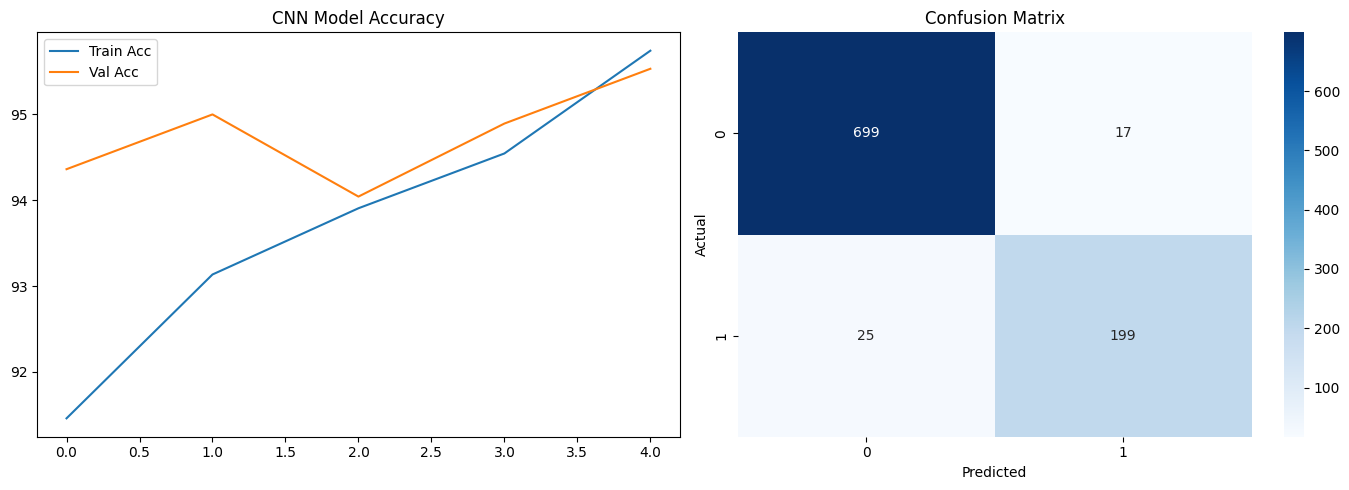

✅ Final Validation Accuracy: 95.53%


In [ ]:
#(WEEK 3, SECTIONS 5 & 6) ---
# This runs the training and plots the results we need

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Training loop
NUM_EPOCHS = 5  # Reduced to 5 for speed
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"Starting training for {NUM_EPOCHS} epochs...")

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_preds, val_labels = validate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"   Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

# PLOT RESULTS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axes[0].plot(history['train_acc'], label='Train Acc')
axes[0].plot(history['val_acc'], label='Val Acc')
axes[0].set_title('CNN Model Accuracy')
axes[0].legend()

# Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print(f"✅ Final Validation Accuracy: {history['val_acc'][-1]:.2f}%")